1. Converted timestamp to datetime format: To enable extraction of temporal information such as hour of day and day of week.
2. Created hour and day_of_week: Mental workload often occurs at specific times, so temporal context may improve prediction performance.
3. Calculated missing counts and percentages: To evaluate data quality and identify sensor reliability issues.
4. Applied linear interpolation to physiological signals: Smartwatch sensors occasionally miss measurements. Interpolation preserves temporal continuity without removing large amounts of data.
5. Replaced missing activity labels with "unknown": Preserves valuable observations while ensuring that all records contain a valid activity category.
6. Checked for duplicate rows: Duplicate observations can bias model training and evaluation.
7. Identified abnormal heart-rate and respiration-rate values: Sensor errors or unrealistic physiological measurements can negatively affect model performance.
8. Removed respiration values outside plausible physiological ranges: Improves data quality and reduces noise.
9. Examined cognitive vs non-cognitive labels: To identify potential class imbalance which may affect model training and evaluation.
10. Selected physiological and temporal variables (heart rate, respiration rate, stress, body battery, hour of day, and day of week): These variables were retained because they may capture both physiological responses and temporal patterns associated with mentally demanding tasks.
11. Standardized continuous variables using StandardScaler: Prevents features with larger numeric ranges from dominating the learning process. Particularly important for SVM and neural networks.
12. Saved full_df_preprocessed.csv: The resulting dataset contains 4,296 observations with no missing values in the selected physiological features and is ready for feature engineering and model development.

### 0 Load and Import

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


In [2]:
# load the dataset
df = pd.read_csv("../final_dfs/full_df.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df

Dataset Shape:
(11520, 9)

Columns:
['timestamp', 'stress', 'body_battery', 'respiration_rate', 'heart_rate', 'sleep_level', 'sleep_score', 'activity_type', 'is_cognitive']


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,NaN,0
1,2026-06-03 00:01:00,12.0,32.0,13.58,NaN,awake,NaN,NaN,0
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,awake,NaN,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,awake,NaN,generic,0
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,awake,NaN,sedentary,0
...,...,...,...,...,...,...,...,...,...
11515,2026-06-10 23:55:00,33.0,21.0,14.66,62.0,awake,63.0,NaN,0
11516,2026-06-10 23:56:00,28.0,21.0,13.91,64.0,awake,63.0,NaN,0
11517,2026-06-10 23:57:00,36.0,21.0,14.91,63.0,awake,63.0,NaN,0
11518,2026-06-10 23:58:00,30.0,21.0,16.33,66.0,awake,63.0,NaN,0


### 1 Handle Time

In [3]:
# Convert Timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.dtypes)


timestamp           datetime64[ns]
stress                     float64
body_battery               float64
respiration_rate           float64
heart_rate                 float64
sleep_level                 object
sleep_score                float64
activity_type               object
is_cognitive                 int64
dtype: object


### 2 Handle Missing Values

                  Missing Count  Missing Percentage
timestamp                     0                0.00
stress                     1162               10.09
body_battery                374                3.25
respiration_rate           2349               20.39
heart_rate                 2219               19.26
sleep_level                   0                0.00
sleep_score                4058               35.23
activity_type              1137                9.87
is_cognitive                  0                0.00


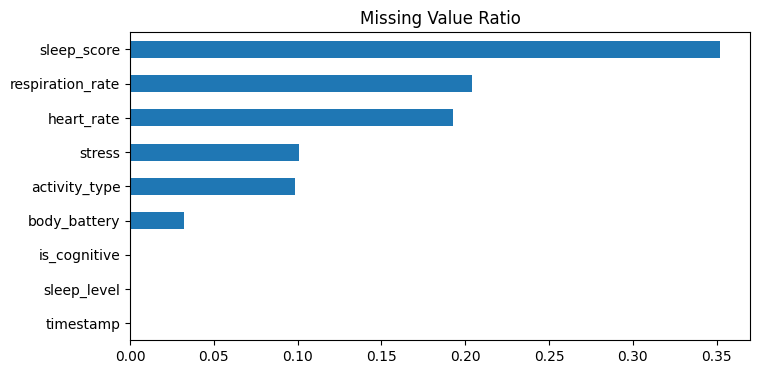

In [4]:
# Missing value analysis

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

print(missing_summary)

plt.figure(figsize=(8,4))

(df.isna().mean().sort_values()).plot(kind="barh")

plt.title("Missing Value Ratio")
plt.show()

In [5]:
sensor_cols = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate"
]

df[sensor_cols] = df[sensor_cols].interpolate(
    method="linear",
    limit_direction="both"
)

In [6]:
print(df.isna().sum())

timestamp              0
stress                 0
body_battery           0
respiration_rate       0
heart_rate             0
sleep_level            0
sleep_score         4058
activity_type       1137
is_cognitive           0
dtype: int64


In [7]:
# Handle Missing Activity Labels
before_rows = len(df)

df["activity_type"] = df["activity_type"].fillna("unknown")

after_rows = len(df)

print("Rows Before:", before_rows)
print("Rows After :", after_rows)
print("Rows Removed:", before_rows - after_rows)

Rows Before: 11520
Rows After : 11520
Rows Removed: 0


In [8]:
# Handle Missing Sleep Score
df["sleep_score"] = df["sleep_score"].ffill().bfill()

In [9]:
# Duplicate Check
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# df = df.drop_duplicates()

Duplicate Rows: 0


### 3 Handle Outliers

In [10]:
# Outlier Detection
hr_outliers = df[
    (df["heart_rate"] < 30) |
    (df["heart_rate"] > 220)
]

print("Heart Rate Outliers:", len(hr_outliers))

resp_outliers = df[
    (df["respiration_rate"] < 5) |
    (df["respiration_rate"] > 40)
]

print("Respiration Outliers:", len(resp_outliers))

Heart Rate Outliers: 20
Respiration Outliers: 113


In [11]:
hr_outliers[
    ["timestamp", "heart_rate"]
].head(20)

,timestamp,heart_rate
6692,2026-06-07 15:32:00,29.75
6693,2026-06-07 15:33:00,28.00
6694,2026-06-07 15:34:00,26.25
6695,2026-06-07 15:35:00,24.50
6696,2026-06-07 15:36:00,22.75
6697,2026-06-07 15:37:00,21.00
6698,2026-06-07 15:38:00,19.25
6699,2026-06-07 15:39:00,17.50
6700,2026-06-07 15:40:00,15.75
6701,2026-06-07 15:41:00,14.00


In [12]:
resp_outliers[
    ["timestamp", "respiration_rate"]
].head(20)

,timestamp,respiration_rate
372,2026-06-03 06:12:00,0.0
373,2026-06-03 06:13:00,0.0
374,2026-06-03 06:14:00,0.0
375,2026-06-03 06:15:00,0.0
376,2026-06-03 06:16:00,0.0
474,2026-06-03 07:54:00,0.0
697,2026-06-03 11:37:00,4.0
698,2026-06-03 11:38:00,2.0
699,2026-06-03 11:39:00,0.0
700,2026-06-03 11:40:00,0.0


In [13]:
# Replace Outliers with NaN

df.loc[
    (df["heart_rate"] < 30) |
    (df["heart_rate"] > 220),
    "heart_rate"
] = np.nan

df.loc[
    (df["respiration_rate"] < 5) |
    (df["respiration_rate"] > 40),
    "respiration_rate"
] = np.nan

# Interpolate Missing Values

df["heart_rate"] = df["heart_rate"].interpolate(
    method="linear",
    limit_direction="both"
)

df["respiration_rate"] = df["respiration_rate"].interpolate(
    method="linear",
    limit_direction="both"
)

print("Heart Rate NaNs:", df["heart_rate"].isna().sum())
print("Respiration Rate NaNs:", df["respiration_rate"].isna().sum())

Heart Rate NaNs: 0
Respiration Rate NaNs: 0


### 4 Check Target

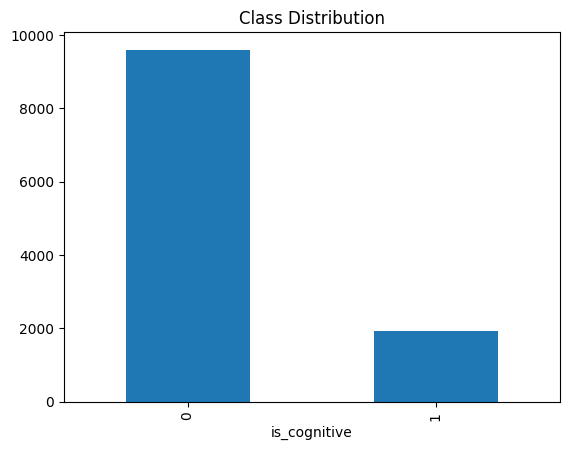

In [14]:
# Target Variable Check
df["is_cognitive"].value_counts()
df["is_cognitive"].value_counts(normalize=True)

df["is_cognitive"].value_counts().plot(kind="bar")

plt.title("Class Distribution")

plt.show()

In [15]:
# Feature Selection
features = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate",
    "day_of_week"
]

target = "is_cognitive"

### Encode Category Data

In [16]:
# Encode Activity Type

df = pd.get_dummies(
    df,
    columns=["activity_type"],
    drop_first=True
)

In [17]:
# Encode Sleep Level

df = pd.get_dummies(
    df,
    columns=["sleep_level"],
    drop_first=True
)

### Final Set

In [18]:
# Final Dataset
print(df.shape)

df.head()

(11520, 15)


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_score,is_cognitive,activity_type_generic,activity_type_running,activity_type_sedentary,activity_type_unknown,activity_type_walking,sleep_level_deep,sleep_level_light,sleep_level_rem
0,2026-06-03 00:00:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
1,2026-06-03 00:01:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,73.0,0,False,False,False,True,False,False,False,False
3,2026-06-03 00:03:00,21.0,32.0,14.91,74.0,73.0,0,True,False,False,False,False,False,False,False
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,73.0,0,False,False,True,False,False,False,False,False


In [19]:
print(
    df["is_cognitive"]
    .value_counts(normalize=True)
)

is_cognitive
0    0.832986
1    0.167014
Name: proportion, dtype: float64


In [20]:
# Verify no missing values remain
print(df.isna().sum())

timestamp                  0
stress                     0
body_battery               0
respiration_rate           0
heart_rate                 0
sleep_score                0
is_cognitive               0
activity_type_generic      0
activity_type_running      0
activity_type_sedentary    0
activity_type_unknown      0
activity_type_walking      0
sleep_level_deep           0
sleep_level_light          0
sleep_level_rem            0
dtype: int64


In [21]:
test=df.to_csv(
    "../final_dfs/full_df_preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


In [22]:
test = pd.read_csv("../final_dfs/full_df_preprocessed.csv")

print(test.shape)

test.head()

(11520, 15)


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_score,is_cognitive,activity_type_generic,activity_type_running,activity_type_sedentary,activity_type_unknown,activity_type_walking,sleep_level_deep,sleep_level_light,sleep_level_rem
0,2026-06-03 00:00:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
1,2026-06-03 00:01:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,73.0,0,False,False,False,True,False,False,False,False
3,2026-06-03 00:03:00,21.0,32.0,14.91,74.0,73.0,0,True,False,False,False,False,False,False,False
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,73.0,0,False,False,True,False,False,False,False,False
